## Question 1: Full Cleaning Pipeline

In [1]:
import numpy as np
import pandas as pd

# Load the CSV into a DataFrame
df = pd.read_csv('lung_cancer_dataset_dirty.csv')

(a) Drop duplicate rows.

In [2]:
# Remove duplicate rows
df = df.drop_duplicates()

(b) Strip extra whitespace from every text column, and normalize the case of Gender, WHO_Region,
BMI_Category, Cancer_Stage, and Treatment (e.g., using .str.title()). Watch out: title-casing turns ''IV''
into ''Iv''. Fix Cancer_Stage’s Roman numerals back afterward.

In [3]:
# Strip extra whitespace
str_cols = df.select_dtypes(include=['str']).columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

# Normalize case on specific columns
cols_to_title = ['Gender', 'WHO_Region', 'BMI_Category', 'Cancer_Stage', 'Treatment']
df[cols_to_title] = df[cols_to_title].apply(lambda col: col.str.title())

# Fix Roman numerals in Cancer_Stage
corrected_numerals = {
    'Stage I': 'Stage I',
    'Stage Ii': 'Stage II',
    'Stage Iii': 'Stage III',
    'Stage Iv': 'Stage IV',
}

df['Cancer_Stage'] = df['Cancer_Stage'].str.replace(r'\s+', ' ', regex=True).str.strip().replace(corrected_numerals)

(c) Convert the two known sentinel placeholders to real missing values: -1 in Tumor_Size_cm, and
''Unknown'' in Alcohol_Use.

In [4]:
# Convert sentinel placeholders to missing values
df['Tumor_Size_cm'] = df['Tumor_Size_cm'].replace({-1:None})
df['Alcohol_Use'] = df['Alcohol_Use'].replace({"Unknown":None})

(d) Fill missing values in Years_Smoking using linear interpolation instead of dropping those rows.

In [5]:
# Fill missing values
df['Years_Smoking'] = df['Years_Smoking'].interpolate(method='linear')

(e) Drop rows with missing values in every other column that still has any.

In [6]:
# Drop rows with missing values
df = df.dropna()

(f) Print the final shape and confirm zero missing values remain. Save this cleaned DataFrame as q1_df,
since you will reuse it in later questions.

In [7]:
# Print the final shape and confirm zero missing values remain.
print(df.shape)

missing_counts = df.isna().sum()
total_missing = missing_counts.sum()

if total_missing == 0:
    print("Confirmed: zero missing values remain.")

q1_df = df.copy()

(1617, 46)
Confirmed: zero missing values remain.


## Question 2: Standardizing Inconsistent Category Labels
The Smoking_Status column contains many different spellings of the same 3 real categories (e.g.,
''CURRENT SMOKER''
''current smoker''
,
,
''Smoker'', and ''Active Smoker'' should all become
''Current Smoker'').
Using q1_df from Question 1, write code to reduce Smoking_Status down to exactly 3 clean categories:
''Current Smoker''
'Former Smoker''
,
,
''Never Smoked''. Print value_counts() before and after to show
the fix.

In [8]:
print(q1_df['Smoking_Status'].value_counts())
q1_df['Smoking_Status'] = q1_df['Smoking_Status'].str.lower().str.strip()
print("\nPost lower and strip:")
print(q1_df['Smoking_Status'].value_counts())

Smoking_Status
Never Smoked      881
Current Smoker    309
Former Smoker     149
NEVER SMOKED       40
never smoked       39
Non-Smoker         29
Never              27
Nonsmoker          25
nEVER sMOKED       23
current smoker     17
CURRENT SMOKER     13
Smoker             12
Current            10
Ex-Smoker           9
Active Smoker       8
cURRENT sMOKER      8
former smoker       5
FORMER SMOKER       5
Former              3
Ex Smoker           3
fORMER sMOKER       2
Name: count, dtype: int64

Post lower and strip:
Smoking_Status
never smoked      983
current smoker    347
former smoker     161
non-smoker         29
never              27
nonsmoker          25
smoker             12
current            10
ex-smoker           9
active smoker       8
former              3
ex smoker           3
Name: count, dtype: int64


In [9]:
corrected_smoking = {
    'former smoker': 'Former Smoker',
    'former': 'Former Smoker',
    'ex smoker': 'Former Smoker',
    'ex-smoker': 'Former Smoker',
    'never smoked': 'Never Smoked',
    'nonsmoker': 'Never Smoked',
    'non-smoker': 'Never Smoked',
    'never': 'Never Smoked',
    'current smoker': 'Current Smoker',
    'active smoker': 'Current Smoker',
    'smoker': 'Current Smoker',
    'current': 'Current Smoker',
}

q1_df['Smoking_Status'] = q1_df['Smoking_Status'].replace(corrected_smoking)
print("Post cleanup:")
print(q1_df['Smoking_Status'].value_counts())


Post cleanup:
Smoking_Status
Never Smoked      1064
Current Smoker     377
Former Smoker      176
Name: count, dtype: int64


## Question 3: Descriptive Statistics
Using the cleaned q1_df (with Smoking_Status also standardized per Question 2), compute the mean,
median, standard deviation, minimum, and maximum of Tumor_Size_cm and BMI. Then use .describe()
to get a full statistical summary of all numeric columns at once.

In [10]:
print(
    "Tumor_size_cm:\n",
    f"Mean: {q1_df['Tumor_Size_cm'].mean()}\n",
    f"Median: {q1_df['Tumor_Size_cm'].median()}\n",
    f"Mode: {q1_df['Tumor_Size_cm'].mode()[0]}\n",
    f"Standard Deviation: {q1_df['Tumor_Size_cm'].std()}\n",
    f"Minimum: {q1_df['Tumor_Size_cm'].min()}\n",
    f"Maximum: {q1_df['Tumor_Size_cm'].max()}\n"
)

print(
    "BMI:\n",
    f"Mean: {q1_df['BMI'].mean()}\n",
    f"Median: {q1_df['BMI'].median()}\n",
    f"Mode: {q1_df['BMI'].mode()[0]}\n",
    f"Standard Deviation: {q1_df['BMI'].std()}\n",
    f"Minimum: {q1_df['BMI'].min()}\n",
    f"Maximum: {q1_df['BMI'].max()}\n"
)

q1_df.describe()

Tumor_size_cm:
 Mean: 4.569758812615949
 Median: 4.3
 Mode: 2.0
 Standard Deviation: 2.3377354286503222
 Minimum: 0.5
 Maximum: 13.3

BMI:
 Mean: 26.554174397031545
 Median: 26.5
 Mode: 23.8
 Standard Deviation: 4.09500679429344
 Minimum: 16.0
 Maximum: 40.0



,Diagnosis_Year,Age,Cigarettes_Per_Day,Years_Smoking,Pack_Years,BMI,Risk_Factor_Count,Symptom_Count,Survival_Months
count,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000
mean,2021.221398,60.827458,7.147805,8.151206,8.880952,26.554174,1.716759,3.341991,31.497835
std,3.303420,10.383693,11.569198,12.745614,16.479982,4.095007,1.089519,1.629303,23.777931
min,2015.000000,30.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,1.000000
25%,2019.000000,53.000000,0.000000,0.000000,0.000000,23.800000,1.000000,2.000000,11.000000
50%,2022.000000,60.000000,0.000000,0.000000,0.000000,26.500000,2.000000,3.000000,26.000000
75%,2024.000000,68.000000,13.000000,16.000000,11.400000,29.400000,2.000000,4.000000,49.000000
max,2026.000000,89.000000,56.000000,59.000000,92.000000,40.000000,6.000000,9.000000,110.000000


## Question 4: Group By and Aggregate
Group the cleaned data by Cancer_Stage and Smoking_Status. For each group, compute the n_patients as
counts, average Survival_Months and average Tumor_Size_cm using .agg(). Which combination of stage
and smoking status has the lowest average survival?

In [11]:
grouped_data = q1_df.groupby(['Cancer_Stage', 'Smoking_Status']).agg(
    n_patients=('Patient_ID', 'count'),
    average_survival=('Survival_Months', 'mean'),
    average_tumor_size=('Tumor_Size_cm', 'mean'))

grouped_data.sort_values('average_survival')

n_patients  average_survival average_tumor_size
Cancer_Stage Smoking_Status                                                 
Stage IV     Current Smoker         140          7.121429           7.197857
             Never Smoked           210          7.442857           7.085238
             Former Smoker           46          8.673913           6.928261
Stage III    Current Smoker         123         17.325203           5.543902
             Never Smoked           198         18.090909           5.495455
             Former Smoker           53         20.226415            5.40566
Stage II     Current Smoker          69         33.521739           4.133333
             Former Smoker           39         34.435897           4.284615
             Never Smoked           289         36.529412           3.963668
Stage I      Current Smoker          45         57.844444           2.102222
             Never Smoked           367         59.746594           2.028883
             Former Smoker           38         64.342105           2.144737

Stage IV, current smokers have the lowest survival (7.12 months)

## Question 5: Visualize with Violin Plots

(a) Tumor_Size_cm distribution across Cancer_Stage categories.


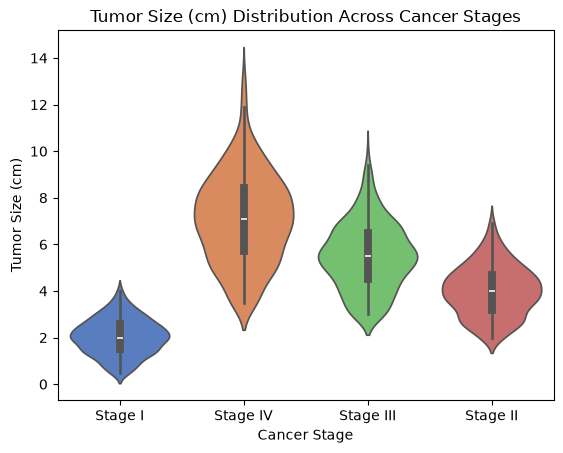

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.violinplot(data=q1_df, x='Cancer_Stage', y='Tumor_Size_cm',  hue='Cancer_Stage', palette='muted', legend=False)
plt.title('Tumor Size (cm) Distribution Across Cancer Stages')
plt.xlabel('Cancer Stage')
plt.ylabel('Tumor Size (cm)')
plt.show()

Mean tumor size increases across stages, from ~2 cm at Stage I up to ~7 cm at Stage IV. Stage IV also has the largest range, with values extending out to ~14 cm.

(b) Survival_Months distribution across Smoking_Status categories.

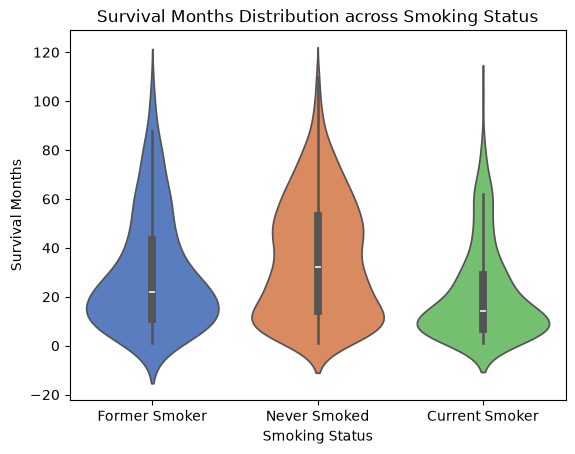

In [13]:
sns.violinplot(data=q1_df, x='Smoking_Status', y='Survival_Months',  hue='Smoking_Status', palette='muted', legend=False)
plt.title('Survival Months Distribution across Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Survival Months')
plt.show()

Never Smoked is spread over the largest range, with a thick, long body extending well into higher survival months. Former Smoker and Current Smoker both show a shorter, wider body concentrated at lower survival months, tapering into a long, thin tail toward higher values. Former Smoker's tail tapers more slowly than Current Smoker's, indicating a lower likelihood that a current smoker survives that long.

## Question 6: Data Loading & Initial Inspection
Load lung_cancer_dataset_dirty.csv into a fresh DataFrame. Print its shape, column dtypes, and the first 5
rows. Then compute the DataFrame’s total memory usage in megabytes using
df.memory_usage(deep=True). Which column consumes the most memory, and why do you think that is?
(Hint: think about how numeric columns are stored in memory versus how text/object columns are
stored.)

In [14]:
df = pd.read_csv('lung_cancer_dataset_dirty.csv')

print(f"shape:\n{df.shape}\n")
print(f"dtypes:\n{df.dtypes}")

display(df.head(5))

print(df.memory_usage(deep=True))
memory_usage_mb = df.memory_usage(deep=True).sum() / 1024 / 1024
print(f"Total memory usage:\n{float(memory_usage_mb):.2f} MB")

shape:
(2040, 46)

dtypes:
Patient_ID                     str
Diagnosis_Year               int64
Diagnosis_Date                 str
WHO_Region                     str
Country                        str
Age                          int64
Age_Group                      str
Gender                         str
Smoking_Status                 str
Cigarettes_Per_Day           int64
Years_Smoking              float64
Pack_Years                 float64
Secondhand_Smoke               str
Family_History                 str
Occupational_Hazard            str
Air_Pollution_Exposure         str
Alcohol_Use                    str
BMI                        float64
BMI_Category                   str
Exercise_Frequency             str
Chronic_Lung_Disease           str
Asbestos_Exposure              str
Radon_Exposure                 str
Previous_Cancer_History        str
Risk_Factor_Count            int64
Genetic_Mutation               str
Coughing                       str
Shortness_of_Breath         

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Symptom_Count,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,...,5,NSCLC,Adenocarcinoma,NaN,6.4,Yes,MRI,chemo + radiation,4,No
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,5,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,3,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,6,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,5,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes


Index                       12936
Patient_ID                  90552
Diagnosis_Year              12936
Diagnosis_Date              95403
WHO_Region                  98897
Country                     90675
Age                         12936
Age_Group                   87318
Gender                      86929
Smoking_Status              99567
Cigarettes_Per_Day          12936
Years_Smoking               12936
Pack_Years                  12936
Secondhand_Smoke            83225
Family_History              82896
Occupational_Hazard         82795
Air_Pollution_Exposure      87736
Alcohol_Use                 92467
BMI                         12936
BMI_Category                91584
Exercise_Frequency          87368
Chronic_Lung_Disease        82781
Asbestos_Exposure           82557
Radon_Exposure              82591
Previous_Cancer_History     82563
Risk_Factor_Count           12936
Genetic_Mutation            89618
Coughing                    83252
Shortness_of_Breath         83165
Chest_Pain    

The Treatment column consumes the most memory. Numeric columns are stored as fixed-size values in a contiguous array, so they all use the same amount of memory regardless of their values. Object/string columns instead store a pointer to a separate Python string object for each row, and each string has extra overhead plus its data. Since Treatment holds longer, more varied strings than other columns, it ends up with the most used memory.

## Question 7: Fixing Placeholder Values with replace()
The dataset contains two placeholder values that are NOT automatically recognized as missing by Pandas:
-1 in Tumor_Size_cm, and the string ''Unknown'' in Alcohol_Use.

(a) Show that isna().sum() does not detect these placeholders: count how many -1 and ''Unknown'' values actually exist.

In [15]:
print((df[['Tumor_Size_cm', 'Alcohol_Use']].isna().sum()).to_string())

print(f"-1 placeholders in Tumor_Size_cm: {(df['Tumor_Size_cm'] == -1).sum()}")
print(f"'Unknown' placeholders in Alcohol_Use: {(df['Alcohol_Use'] == 'Unknown').sum()}")

Tumor_Size_cm    63
Alcohol_Use      42
-1 placeholders in Tumor_Size_cm: 19
'Unknown' placeholders in Alcohol_Use: 32


(b) Use .replace() to convert both placeholders into real NaN.

In [16]:
df['Tumor_Size_cm'] = df['Tumor_Size_cm'].replace({-1:np.nan})
df['Alcohol_Use'] = df['Alcohol_Use'].replace({'Unknown':np.nan})

(c) Confirm the missing-value counts increased afterward, and explain in one sentence why isna() could
not find these on its own.

In [17]:
print((df[['Tumor_Size_cm', 'Alcohol_Use']].isna().sum()).to_string())

Tumor_Size_cm    82
Alcohol_Use      74


`isna()` is only designed to find true NaN, None, or NaT values. Values like -1 or ''Unknown'', while they tell us that there are missing values, to `isna()` they are just normal typed data.

## Question 8: Advanced Interpolation: Limits and Curve Methods
Using a fresh copy of the raw data sorted by Diagnosis_Year, take the first 15 rows of the BMI column as
a small Series. Introduce a few artificial NaN values into it (for example, at positions 2, 3, and 10). Then:

In [18]:
q8_df = pd.read_csv('lung_cancer_dataset_dirty.csv').sort_values('Diagnosis_Year')

bmi_series = q8_df['BMI'].head(15).copy()
bmi_series = bmi_series.reset_index(drop=True)

bmi_series.iloc[[2, 3, 10]] = np.nan

bmi_series

0     30.8
1     30.6
2      NaN
3      NaN
4     26.1
5     22.7
6     17.5
7      NaN
8      NaN
9     30.8
10     NaN
11    29.9
12    18.3
13    25.8
14    31.0
Name: BMI, dtype: float64

(a) Interpolate using method=`linear’ with limit=1, and explain what changes compared to interpolating
with no limit.

In [19]:
bmi_series_1 = bmi_series.interpolate(method='linear', limit=1)
bmi_series_1

0     30.800000
1     30.600000
2     29.100000
3           NaN
4     26.100000
5     22.700000
6     17.500000
7     21.933333
8           NaN
9     30.800000
10    30.350000
11    29.900000
12    18.300000
13    25.800000
14    31.000000
Name: BMI, dtype: float64

With no limit interpolate() will linearly interpolate all NaN values regardless of how many consecutive NaN values there are, with limit=1, interpolate() will only linearly interpolate the first NaN in every sequence that appears in the series.

(b) Interpolate using limit_direction=`both’, and explain when this setting matters.

In [20]:
bmi_series_2 = bmi_series.interpolate(method='linear', limit_direction='both')
bmi_series_2

0     30.800000
1     30.600000
2     29.100000
3     27.600000
4     26.100000
5     22.700000
6     17.500000
7     21.933333
8     26.366667
9     30.800000
10    30.350000
11    29.900000
12    18.300000
13    25.800000
14    31.000000
Name: BMI, dtype: float64

By default, `interpolate()` only fills NaN values that have a valid value before them (forward interpolation). If a NaN value is at the beginning of the Series, before any valid value, there's nothing to interpolate from, so it stays NaN regardless of the limit. limit_direction='both' fixes this by also interpolating backward, using the next valid value after the gap to fill the previous NaN values.

(c) Compare linear, pchip, and akima interpolation methods on this same Series and comment on any
differences you observe.

In [21]:
bmi_series_linear = bmi_series.interpolate(method='linear')
bmi_series_pchip = bmi_series.interpolate(method='pchip')
bmi_series_akima = bmi_series.interpolate(method='akima')

comparison = pd.DataFrame({
    'linear': bmi_series_linear,
    'pchip': bmi_series_pchip,
    'akima': bmi_series_akima
})

comparison

,linear,pchip,akima
0,30.800000,30.800000,30.800000
1,30.600000,30.600000,30.600000
2,29.100000,29.788748,29.620116
3,27.600000,28.186192,28.125650
4,26.100000,26.100000,26.100000
5,22.700000,22.700000,22.700000
6,17.500000,17.500000,17.500000
7,21.933333,20.948148,19.307966
8,26.366667,27.351852,25.808478
9,30.800000,30.800000,30.800000


Linear draws a straight line between the two points around each gap. pchip and akima both fit curves instead, so they tend to be closer to each other than to linear, specifically where the surrounding data has some amount of curvature. The biggest differences show up at index 7, since it's preceded by a sharp dip and followed by a sharp rise. akima gives a noticeably lower value than pchip and linear, since it reacts more to the steep slope on either side of the gap. pchip stays more conservative because it's designed to be monotonic and prevent overshooting. In the flatter parts of the series, all three methods interpolate very similar values, since there isn't much curvature for pchip or akima to act on.

## Question 9: Feature Engineering, Encoding, and Scaling
Using the cleaned dataset from Question 1 (q1_df):

(a) Engineer a new column Pack_Years_Per_Year_Smoking = Pack_Years / Years_Smoking (handle
divide-by-zero safely so it doesn’t crash or produce infinite values).

In [22]:
q1_df['Pack_Years_Per_Year_Smoking'] = np.where(q1_df['Years_Smoking'] == 0, np.nan, q1_df['Pack_Years'] / q1_df['Years_Smoking'])
q1_df

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived,Pack_Years_Per_Year_Smoking
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes,0.25
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No,NaN
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No,1.05
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes,NaN
5,LC-0006,2026,2026-01-01,Eastern Mediterranean,Iran,75,70-79,Male,Never Smoked,0,...,NSCLC,Adenocarcinoma,Stage II,3.0,No,CT Scan,Surgery,23,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,LC-1996,2023,2023-05-23,Europe,Sweden,58,50-59,Female,Current Smoker,23,...,NSCLC,Large Cell,Stage IV,4.3,Yes,CT Scan,Immunotherapy,2,No,1.16
1996,LC-1997,2020,2020-01-25,Americas,Brazil,55,50-59,Male,Current Smoker,37,...,SCLC,Not Applicable,Stage IV,6.9,Yes,MRI,Palliative Care,13,No,1.85
1997,LC-1998,2022,2022-11-16,Europe,Poland,75,70-79,Female,Never Smoked,0,...,NSCLC,Large Cell,Stage II,2.6,No,Biopsy,Chemotherapy,36,Yes,NaN
1998,LC-1999,2025,2025-01-07,Western Pacific,Singapore,38,30-39,Female,Never Smoked,0,...,NSCLC,Adenocarcinoma,Stage II,3.8,No,PET Scan,Surgery + Chemotherapy,36,No,NaN


(b) One-hot encode the Cancer_Type column using pd.get_dummies().

In [23]:
dummies = pd.get_dummies(q1_df['Cancer_Type'])
q1_df = pd.concat([q1_df, dummies], axis=1)
q1_df

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived,Pack_Years_Per_Year_Smoking,NSCLC,SCLC
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes,0.25,True,False
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,Stage I,2.9,No,LDCT Screening,Surgery,69,No,NaN,True,False
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No,1.05,True,False
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes,NaN,True,False
5,LC-0006,2026,2026-01-01,Eastern Mediterranean,Iran,75,70-79,Male,Never Smoked,0,...,Stage II,3.0,No,CT Scan,Surgery,23,No,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,LC-1996,2023,2023-05-23,Europe,Sweden,58,50-59,Female,Current Smoker,23,...,Stage IV,4.3,Yes,CT Scan,Immunotherapy,2,No,1.16,True,False
1996,LC-1997,2020,2020-01-25,Americas,Brazil,55,50-59,Male,Current Smoker,37,...,Stage IV,6.9,Yes,MRI,Palliative Care,13,No,1.85,False,True
1997,LC-1998,2022,2022-11-16,Europe,Poland,75,70-79,Female,Never Smoked,0,...,Stage II,2.6,No,Biopsy,Chemotherapy,36,Yes,NaN,True,False
1998,LC-1999,2025,2025-01-07,Western Pacific,Singapore,38,30-39,Female,Never Smoked,0,...,Stage II,3.8,No,PET Scan,Surgery + Chemotherapy,36,No,NaN,True,False


(c) Apply min-max scaling to Tumor_Size_cm into a new column Tumor_Size_Scaled (range 0 to 1).

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
q1_df['Tumor_Size_Scaled'] = scaler.fit_transform(q1_df[['Tumor_Size_cm']])
q1_df

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived,Pack_Years_Per_Year_Smoking,NSCLC,SCLC,Tumor_Size_Scaled
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes,0.25,True,False,0.164062
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,2.9,No,LDCT Screening,Surgery,69,No,NaN,True,False,0.187500
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,7.0,Yes,CT Scan,Chemotherapy,9,No,1.05,True,False,0.507812
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,5.8,No,Bronchoscopy,Immunotherapy,5,Yes,NaN,True,False,0.414062
5,LC-0006,2026,2026-01-01,Eastern Mediterranean,Iran,75,70-79,Male,Never Smoked,0,...,3.0,No,CT Scan,Surgery,23,No,NaN,True,False,0.195312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,LC-1996,2023,2023-05-23,Europe,Sweden,58,50-59,Female,Current Smoker,23,...,4.3,Yes,CT Scan,Immunotherapy,2,No,1.16,True,False,0.296875
1996,LC-1997,2020,2020-01-25,Americas,Brazil,55,50-59,Male,Current Smoker,37,...,6.9,Yes,MRI,Palliative Care,13,No,1.85,False,True,0.500000
1997,LC-1998,2022,2022-11-16,Europe,Poland,75,70-79,Female,Never Smoked,0,...,2.6,No,Biopsy,Chemotherapy,36,Yes,NaN,True,False,0.164062
1998,LC-1999,2025,2025-01-07,Western Pacific,Singapore,38,30-39,Female,Never Smoked,0,...,3.8,No,PET Scan,Surgery + Chemotherapy,36,No,NaN,True,False,0.257812


Print the first 5 rows showing all three new columns alongside their source columns.

In [25]:
q1_df[['Pack_Years', 'Years_Smoking', 'Pack_Years_Per_Year_Smoking', 'Cancer_Type', 'NSCLC', 'SCLC', 'Tumor_Size_cm', 'Tumor_Size_Scaled']].head(5)

,Pack_Years,Years_Smoking,Pack_Years_Per_Year_Smoking,Cancer_Type,NSCLC,SCLC,Tumor_Size_cm,Tumor_Size_Scaled
1,8.5,34.0,0.25,NSCLC,True,False,2.6,0.164062
2,0.0,0.0,NaN,NSCLC,True,False,2.9,0.187500
3,35.7,34.0,1.05,NSCLC,True,False,7.0,0.507812
4,0.0,0.0,NaN,NSCLC,True,False,5.8,0.414062
5,0.0,0.0,NaN,NSCLC,True,False,3.0,0.195312


## Question 10: Pivot Tables, Ranking, and Cumulative Statistics
Using the cleaned dataset from Question 1 (q1_df):

(a) Build a pivot table showing average Survival_Months by Cancer_Stage (rows) and Gender (columns).

In [26]:
pivot_survival = q1_df.pivot_table(
    values='Survival_Months',
    index='Cancer_Stage',
    columns='Gender',
    aggfunc='mean'
)

pivot_survival

Gender,Female,Male
Cancer_Stage,,
Stage I,61.796954,58.501976
Stage II,34.879518,36.463203
Stage III,19.302521,17.600000
Stage IV,7.507576,7.454545


(b) Within each Cancer_Stage group, rank patients by Tumor_Size_cm using groupby().rank(), so that the
largest tumor in each stage gets rank 1.

In [27]:
q1_df['Tumor_Size_Rank'] = q1_df.groupby('Cancer_Stage')['Tumor_Size_cm'].rank(ascending=False)
q1_df

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived,Pack_Years_Per_Year_Smoking,NSCLC,SCLC,Tumor_Size_Scaled,Tumor_Size_Rank
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,No,Biopsy,Surgery + Chemotherapy,76,Yes,0.25,True,False,0.164062,108.0
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,No,LDCT Screening,Surgery,69,No,NaN,True,False,0.187500,66.0
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,Yes,CT Scan,Chemotherapy,9,No,1.05,True,False,0.507812,205.5
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,No,Bronchoscopy,Immunotherapy,5,Yes,NaN,True,False,0.414062,144.0
5,LC-0006,2026,2026-01-01,Eastern Mediterranean,Iran,75,70-79,Male,Never Smoked,0,...,No,CT Scan,Surgery,23,No,NaN,True,False,0.195312,315.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,LC-1996,2023,2023-05-23,Europe,Sweden,58,50-59,Female,Current Smoker,23,...,Yes,CT Scan,Immunotherapy,2,No,1.16,True,False,0.296875,366.0
1996,LC-1997,2020,2020-01-25,Americas,Brazil,55,50-59,Male,Current Smoker,37,...,Yes,MRI,Palliative Care,13,No,1.85,False,True,0.500000,213.5
1997,LC-1998,2022,2022-11-16,Europe,Poland,75,70-79,Female,Never Smoked,0,...,No,Biopsy,Chemotherapy,36,Yes,NaN,True,False,0.164062,355.0
1998,LC-1999,2025,2025-01-07,Western Pacific,Singapore,38,30-39,Female,Never Smoked,0,...,No,PET Scan,Surgery + Chemotherapy,36,No,NaN,True,False,0.257812,227.0


In [28]:
q1_df = q1_df.sort_values('Diagnosis_Year')
q1_df['Survival_Months_Cumsum'] = q1_df['Survival_Months'].cumsum()
q1_df[['Diagnosis_Year', 'Survival_Months', 'Survival_Months_Cumsum']]

,Diagnosis_Year,Survival_Months,Survival_Months_Cumsum
696,2015,24,24
1510,2015,26,50
1512,2015,12,62
539,2015,26,88
890,2015,49,137
...,...,...,...
872,2026,36,50775
191,2026,56,50831
548,2026,12,50843
1541,2026,55,50898


The cumulative sum represents the running total of Survival_Months values as they appear in Diagnosis_Year order, it does not represent any meaningful real-world quantity. This is because summing survival months across different, unrelated patients has no direct relevance to the data.